## Eye Diseases Classification

In this notebook we study eye diseases classification. Our model focuses on four main classes of eye diseases:

#### Cataract
Cataract is a disease in which the lens of the eye becomes cloudy, leading to vision loss. It is usually associated with aging, but some health conditions, such as diabetes, can also be a risk factor. Cataracts can significantly reduce the quality of vision, but can be treated with surgery.

### Diabetic Retinopathy
Diabetic retinopathy is a complication of diabetes that results from damage to the retinal vessels in the eye. It may be asymptomatic in the early stages, but as it progresses, it can lead to vision loss. If left untreated, it increases the risk of blindness.

### Glaucoma (Glaucoma)
Glaucoma refers to a group of eye diseases that damage the optic nerve in the eye, leading to vision loss. It is usually associated with elevated intraocular pressure. If not diagnosed early, it can cause permanent vision loss. Treatment can be with medication or surgery.

#### Normal (Healthy Eye)
Healthy eyes are eyes that do not show any signs of disease or discomfort. This class represents individuals without any pathologic condition in the eye.

---

## 1. Libraries and Setup


In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)


LIBS ARE IMPORTED


Tensorflow version  2.19.0


## 2. Dataset Loading


In [12]:
from google.colab import drive

drive.mount('/content/drive')
dataset_dir = '/content/drive/MyDrive/old_state_of_art/dataset'

class_names = sorted(os.listdir(dataset_dir))
num_class = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_class}")

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='training',
    batch_size=32,
    image_size=(256, 256),
    seed=123,
    shuffle=True,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='validation',
    batch_size=32,
    image_size=(256, 256),
    seed=42,
)

print("Training image shape:", next(iter(train_ds))[0][0].shape)
print("Validation image shape:", next(iter(val_ds))[0][0].shape)


Mounted at /content/drive
Class Names: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Number of Classes: 4


Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.


Shape of the first image in the training dataset: (256, 256, 3)
Shape of the first image in the validation dataset: (256, 256, 3)


## 3. Preprocessing and Augmentation


In [20]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.GaussianNoise(0.05),
])


## Inception Model and Layer Additions
In this project, we used the pre-trained **InceptionV3** model. **InceptionV3** is a deep learning model that is highly successful in visual classification tasks. However, we didn't just output the base model, instead we stopped the last layers of the model and added our own custom layers.

The purpose of stopping the final layers of the model is to leverage the feature extraction capacity of the pre-trained model, but customize the final classification layers to our specific classification of eye diseases.

#### Layers We Added:
At the end of the model, we added **Dense** layers to classify the eye disease classes appropriately. We also performed multiclass classification using **softmax** activation function in the last layer. This allows us to accurately predict between four different classes (Cataract, Diabetic Retinopathy, Glaucoma, Normal).

In [25]:
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(256, 256, 3))
cut_layer = base_model.get_layer('mixed8')
truncated_model = Model(inputs=base_model.input, outputs=cut_layer.output)
truncated_model.trainable = True

inputs = tf.keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = truncated_model(x, training=True)
x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 6, 6, 1280)     │    10,674,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 6, 6, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 6, 6, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,987,236 (53.36 MB)

 Trainable params: 13,965,092 (53.27 MB)

 Non-trainable params: 22,144 (86.50 KB)

## 4. Training Configuration


In [30]:
labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(zip(np.unique(labels), class_weights))
print("Class weights:", class_weight_dict)

train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, depth=4)))
val_ds = val_ds.map(lambda x, y: (x, tf.one_hot(y, depth=4)))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.F1Score(average='macro', name='f1_score')
    ]
)


{np.int32(0): np.float64(1.0089712918660287), np.int32(1): np.float64(0.954185520361991), np.int32(2): np.float64(1.0517456359102244), np.int32(3): np.float64(0.9900234741784038)}


In [32]:
def lr_schedule(epoch):
    initial_lr = 0.001
    drop_factor = 0.5
    drop_every = 5
    return initial_lr * (drop_factor ** (epoch // drop_every))

model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
    mode='max',
    save_freq='epoch',
    save_weights_only=False
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=50,
    mode='max',
    verbose=1,
    restore_best_weights=True,
    baseline=0.99,
    min_delta=0.001
)

lr_scheduler = LearningRateScheduler(lr_schedule)

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint, lr_scheduler],
    verbose=1,
    class_weight=class_weight_dict
)


Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6220 - auc: 0.8428 - f1_score: 0.6203 - loss: 0.9521 - precision: 0.7198 - recall: 0.4879
Epoch 1: val_accuracy improved from -inf to 0.57177, saving model to best_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 100s 508ms/step - accuracy: 0.6227 - auc: 0.8432 - f1_score: 0.6209 - loss: 0.9510 - precision: 0.7202 - recall: 0.4889 - val_accuracy: 0.5718 - val_auc: 0.7479 - val_f1_score: 0.4924 - val_loss: 1.6595 - val_precision: 0.6471 - val_recall: 0.5374 - learning_rate: 0.0010
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.7624 - auc: 0.9315 - f1_score: 0.7632 - loss: 0.6299 - precision: 0.7996 - recall: 0.7160
Epoch 2: val_accuracy did not improve from 0.57177
106/106 ━━━━━━━━━━━━━━━━━━━━ 44s 415ms/step - accuracy: 0.7626 - auc: 0.9316 - f1_score: 0.7634 - loss: 0.6295 - precision: 0.7998 - recall: 0.7162 - val_accuracy: 0.3381 - val_auc: 0.6327 - val_f1_score: 0.2349 - val_loss: 4.0947 - val_precision

## 5. Training Results


Training Accuracy: 0.9620628356933594
Validation Accuracy: 0.9311981201171875


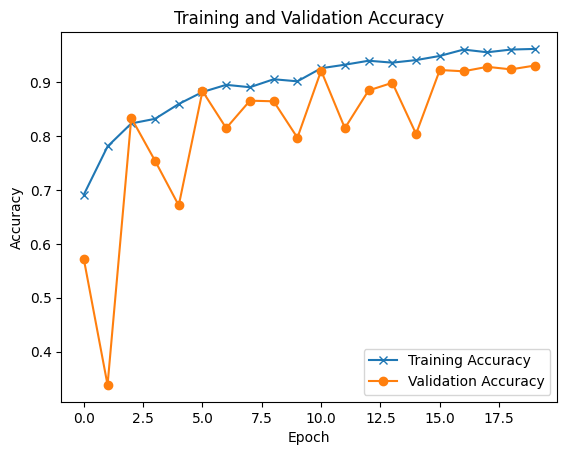

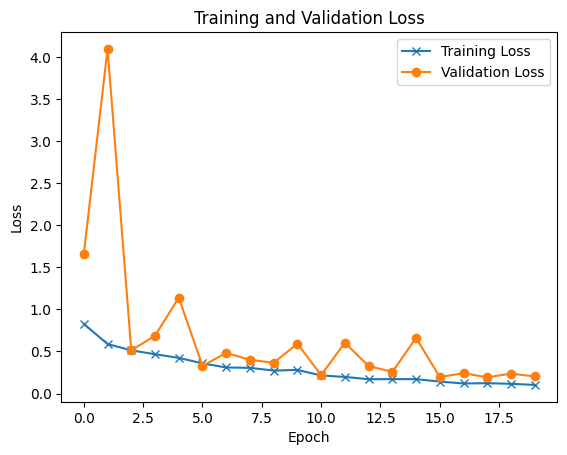

In [35]:
history_dict = history.history
print("Training Accuracy:", history_dict['accuracy'][-1])
print("Validation Accuracy:", history_dict['val_accuracy'][-1])

plt.plot(history_dict['accuracy'], label='Training Accuracy', marker='x')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history_dict['loss'], label='Training Loss', marker='x')
plt.plot(history_dict['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


## 6. Evaluation


In [38]:
model = load_model('best_model.keras')
results = model.evaluate(val_ds, return_dict=True)

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9261 - auc: 0.9887 - f1_score: 0.9253 - loss: 0.2097 - precision: 0.9269 - recall: 0.9253
accuracy: 0.9312
auc: 0.9897
f1_score: 0.9309
loss: 0.2037
precision: 0.9321
recall: 0.9288


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

Confusion Matrix:
[[198   0   2   4]
 [  0 210   1   6]
 [  6   0 193   2]
 [  6  11  20 184]]


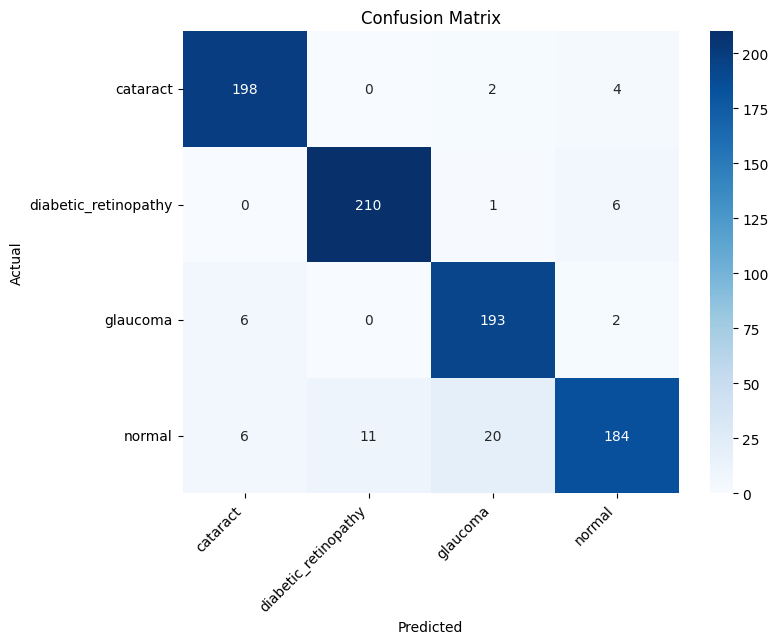

Classification Report:
                       precision    recall  f1-score   support

            cataract       0.94      0.97      0.96       204
diabetic_retinopathy       0.95      0.97      0.96       217
            glaucoma       0.89      0.96      0.93       201
              normal       0.94      0.83      0.88       221

            accuracy                           0.93       843
           macro avg       0.93      0.93      0.93       843
        weighted avg       0.93      0.93      0.93       843



In [44]:
y_true = []
y_pred = []
y_pred_proba = []

for x_batch, y_batch in val_ds:
    probs = model.predict(x_batch)
    preds = np.argmax(probs, axis=1)
    y_true_batch = np.argmax(y_batch.numpy(), axis=1) if y_batch.numpy().ndim > 1 else y_batch.numpy()

    y_true.extend(y_true_batch)
    y_pred.extend(preds)
    y_pred_proba.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:
", report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

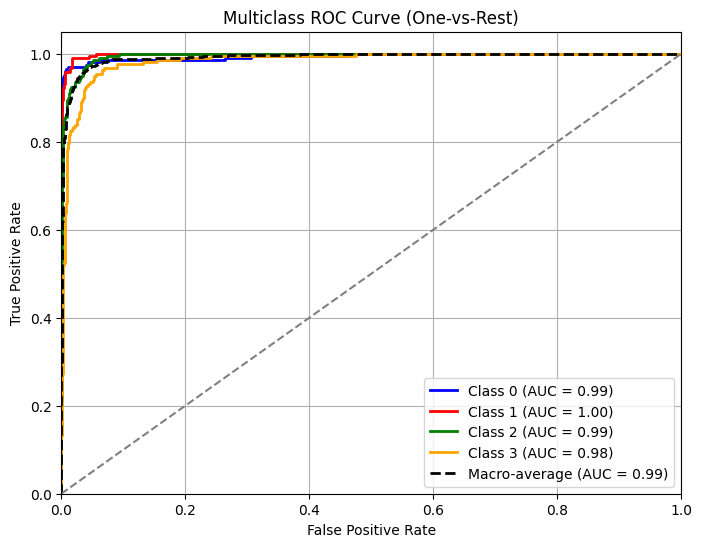

In [46]:
n_classes = y_pred_proba.shape[1]
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['macro'], tpr['macro'], _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'{class_names[i]} AUC = {roc_auc[i]:.2f}')

plt.plot(fpr['macro'], tpr['macro'], color='black', linestyle='--', lw=2, label=f'Macro-average AUC = {roc_auc["macro"]:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## 7. Prediction Helper and Model Saving


In [47]:
def predict(model, img):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

model.save('my_model.keras')
